<a href="https://colab.research.google.com/github/Tagnetcap/Data_science_Assignment/blob/main/global_terrorism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='ISO-8859-1')

# Display the first 5 rows of the DataFrame
display(df.head())

/tmp/ipykernel_1677/1647693498.py:4: DtypeWarning: Columns (4,6,31,33,61,62,63,76,79,90,92,94,96,114,115,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Global Terrorism Data.csv', encoding='ISO-8859-1')


,eventid,iyear,imonth,iday,approxdate,extended,resolution,country,country_txt,region,...,addnotes,scite1,scite2,scite3,dbsource,INT_LOG,INT_IDEO,INT_MISC,INT_ANY,related
0,197000000001,1970,7,2,NaN,0,NaN,58,Dominican Republic,2,...,NaN,NaN,NaN,NaN,PGIS,0,0,0,0,NaN
1,197000000002,1970,0,0,NaN,0,NaN,130,Mexico,1,...,NaN,NaN,NaN,NaN,PGIS,0,1,1,1,NaN
2,197001000001,1970,1,0,NaN,0,NaN,160,Philippines,5,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
3,197001000002,1970,1,0,NaN,0,NaN,78,Greece,8,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN
4,197001000003,1970,1,0,NaN,0,NaN,101,Japan,4,...,NaN,NaN,NaN,NaN,PGIS,-9,-9,1,1,NaN


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181691 entries, 0 to 181690
Columns: 135 entries, eventid to related
dtypes: float64(55), int64(22), object(58)
memory usage: 187.1+ MB
None


In [3]:
display(df.describe())

,eventid,iyear,imonth,iday,extended,country,region,latitude,longitude,specificity,...,ransomamt,ransomamtus,ransompaid,ransompaidus,hostkidoutcome,nreleased,INT_LOG,INT_IDEO,INT_MISC,INT_ANY
count,1.816910e+05,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,181691.000000,177135.000000,1.771340e+05,181685.000000,...,1.350000e+03,5.630000e+02,7.740000e+02,552.000000,10991.000000,10400.000000,181691.000000,181691.000000,181691.000000,181691.000000
mean,2.002705e+11,2002.638997,6.467277,15.505644,0.045346,131.968501,7.160938,23.498343,-4.586957e+02,1.451452,...,3.172530e+06,5.784865e+05,7.179437e+05,240.378623,4.629242,-29.018269,-4.543731,-4.464398,0.090010,-3.945952
std,1.325957e+09,13.259430,3.388303,8.814045,0.208063,112.414535,2.933408,18.569242,2.047790e+05,0.995430,...,3.021157e+07,7.077924e+06,1.014392e+07,2940.967293,2.035360,65.720119,4.543547,4.637152,0.568457,4.691325
min,1.970000e+11,1970.000000,0.000000,0.000000,0.000000,4.000000,1.000000,-53.154613,-8.618590e+07,1.000000,...,-9.900000e+01,-9.900000e+01,-9.900000e+01,-99.000000,1.000000,-99.000000,-9.000000,-9.000000,-9.000000,-9.000000
25%,1.991021e+11,1991.000000,4.000000,8.000000,0.000000,78.000000,5.000000,11.510046,4.545640e+00,1.000000,...,0.000000e+00,0.000000e+00,-9.900000e+01,0.000000,2.000000,-99.000000,-9.000000,-9.000000,0.000000,-9.000000
50%,2.009022e+11,2009.000000,6.000000,15.000000,0.000000,98.000000,6.000000,31.467463,4.324651e+01,1.000000,...,1.500000e+04,0.000000e+00,0.000000e+00,0.000000,4.000000,0.000000,-9.000000,-9.000000,0.000000,0.000000
75%,2.014081e+11,2014.000000,9.000000,23.000000,0.000000,160.000000,10.000000,34.685087,6.871033e+01,1.000000,...,4.000000e+05,0.000000e+00,1.273412e+03,0.000000,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2.017123e+11,2017.000000,12.000000,31.000000,1.000000,1004.000000,12.000000,74.633553,1.793667e+02,5.000000,...,1.000000e+09,1.320000e+08,2.750000e+08,48000.000000,7.000000,2769.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace('[^a-zA-Z0-9_]', '', regex=True)
print('Cleaned column names:')
print(df.columns)

Cleaned column names:
Index(['eventid', 'iyear', 'imonth', 'iday', 'approxdate', 'extended',
       'resolution', 'country', 'country_txt', 'region',
       ...
       'addnotes', 'scite1', 'scite2', 'scite3', 'dbsource', 'int_log',
       'int_ideo', 'int_misc', 'int_any', 'related'],
      dtype='object', length=135)


In [5]:
# Calculate the percentage of missing values for each column
missing_values_percentage = df.isnull().sum() * 100 / len(df)

# Display columns with missing values, sorted by percentage
missing_values_df = pd.DataFrame({'column_name': missing_values_percentage.index, 'missing_percentage': missing_values_percentage.values})
missing_values_df = missing_values_df[missing_values_df['missing_percentage'] > 0].sort_values(by='missing_percentage', ascending=False)

display(missing_values_df.reset_index(drop=True).head(20)) # Display top 20 columns with most missing values

,column_name,missing_percentage
0,gsubname3,99.988992
1,weapsubtype4_txt,99.961473
2,weapsubtype4,99.961473
3,weaptype4_txt,99.959822
4,weaptype4,99.959822
5,claimmode3,99.926799
6,claimmode3_txt,99.926799
7,gsubname2,99.911938
8,claim3,99.824978
9,guncertain3,99.823877


The output above shows a significant number of columns with missing values, some with over 99% missing. This initial analysis helps us determine which columns might be unsuitable for direct use due to excessive missing data and which ones require imputation or other handling strategies.

In [6]:
# Drop columns with more than 70% missing values
# The threshold of 70% is chosen as a common practice to remove columns that are largely empty and unlikely to provide much useful information.
columns_to_drop = missing_values_df[missing_values_df['missing_percentage'] > 70]['column_name'].tolist()
df = df.drop(columns=columns_to_drop)

print(f"Dropped {len(columns_to_drop)} columns with more than 70% missing values.")
print(f"Remaining columns: {df.shape[1]}")

Dropped 71 columns with more than 70% missing values.
Remaining columns: 64


Now that we've removed columns with a high percentage of missing values, we need to address the remaining missing values in other columns. For this, we'll implement specific imputation strategies based on the nature of each column. Numerical columns might be filled with the mean or median, while categorical columns can be filled with their mode or a placeholder like 'Unknown'.

In [7]:
# Impute missing numerical values with the median
# The median is often preferred over the mean for imputation when the data might be skewed by outliers.
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Impute missing categorical values with 'Unknown'
# For categorical columns, creating an 'Unknown' category is a robust way to handle missing data without altering existing distributions.
for col in df.select_dtypes(include=['object']).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna('Unknown')

print("Missing values handled for remaining columns.")
# Verify that there are no more missing values
print("Total missing values after handling:", df.isnull().sum().sum())

Missing values handled for remaining columns.
Total missing values after handling: 0


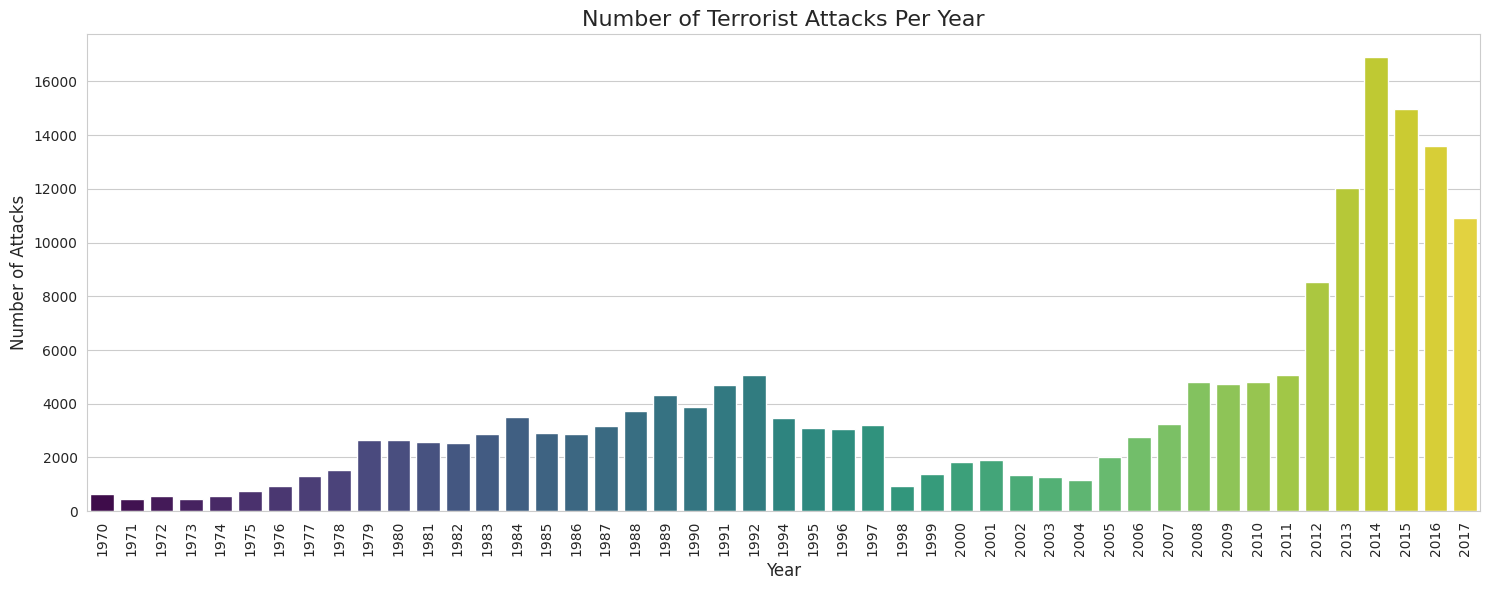

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Visualization 1: Number of terrorist attacks per year
plt.figure(figsize=(15, 6))
sns.countplot(x='iyear', data=df, palette='viridis', hue='iyear', legend=False)
plt.title('Number of Terrorist Attacks Per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

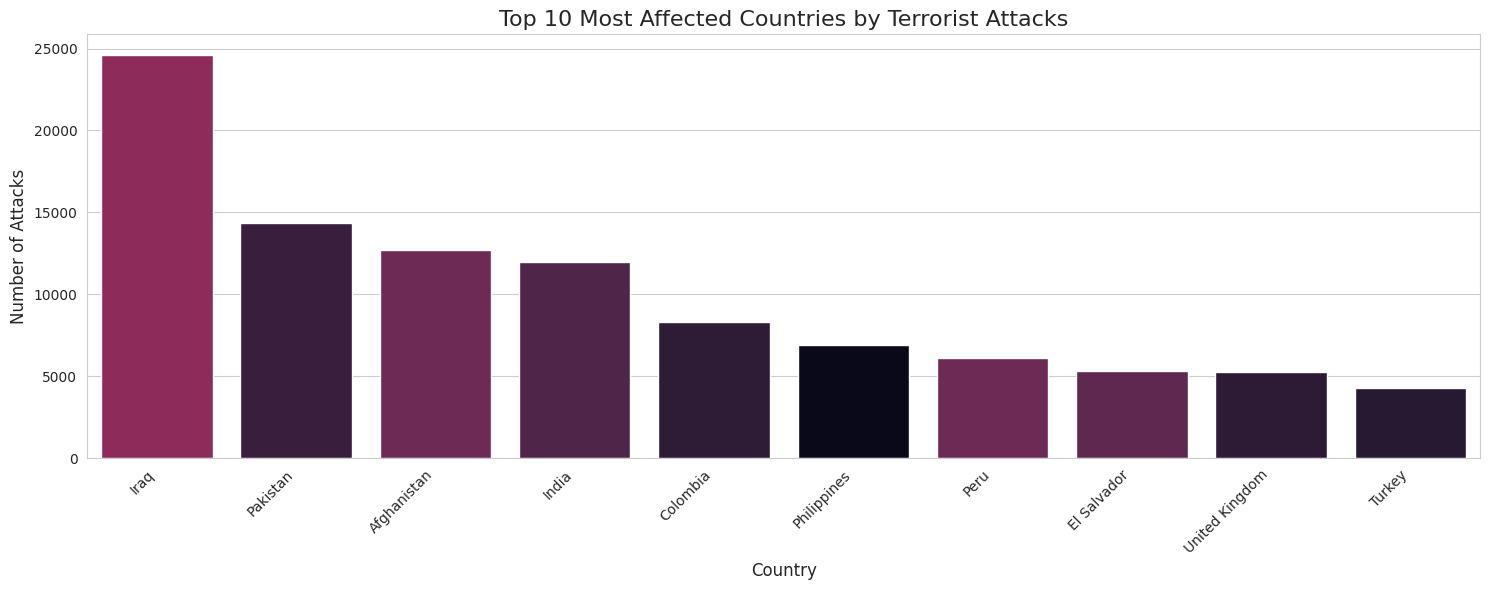

In [11]:
# Visualization 2: Top 10 most affected countries
plt.figure(figsize=(15, 6))
sns.countplot(x='country_txt', data=df, order=df['country_txt'].value_counts().index[:10], palette='rocket', hue='country_txt', legend=False)
plt.title('Top 10 Most Affected Countries by Terrorist Attacks', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

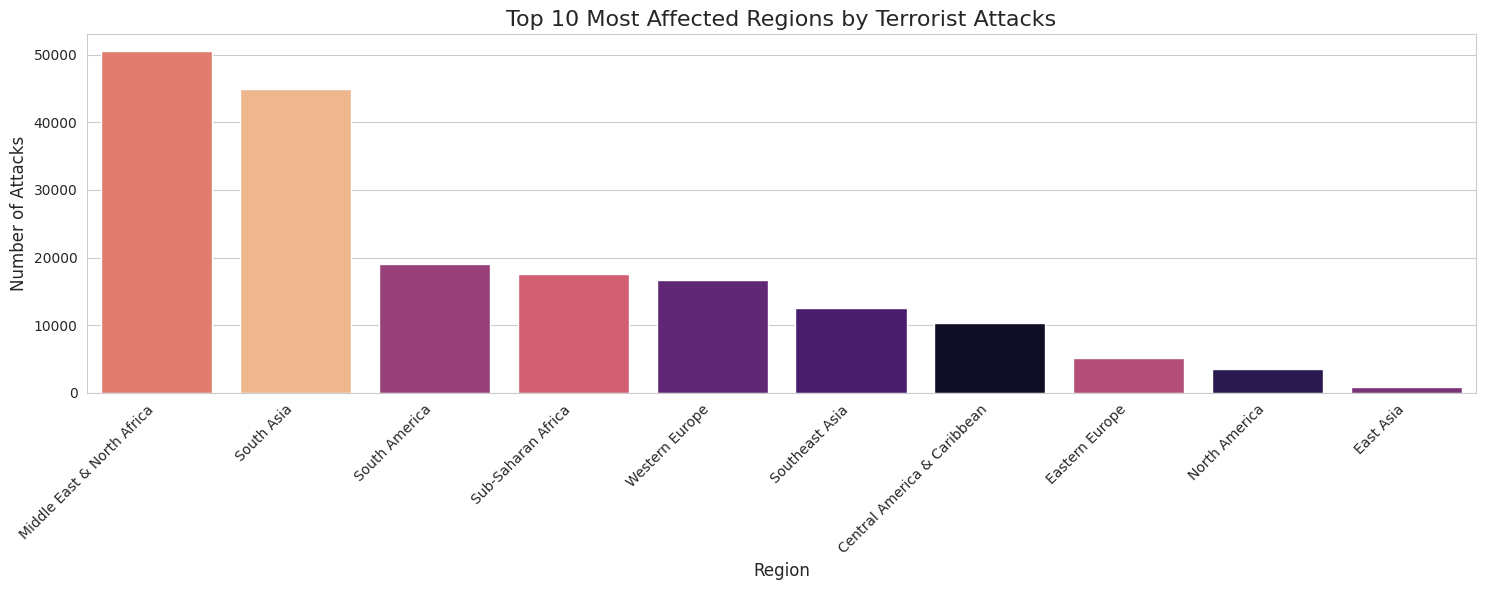

In [12]:
# Visualization 3: Top 10 most affected regions
plt.figure(figsize=(15, 6))
sns.countplot(x='region_txt', data=df, order=df['region_txt'].value_counts().index[:10], palette='magma', hue='region_txt', legend=False)
plt.title('Top 10 Most Affected Regions by Terrorist Attacks', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

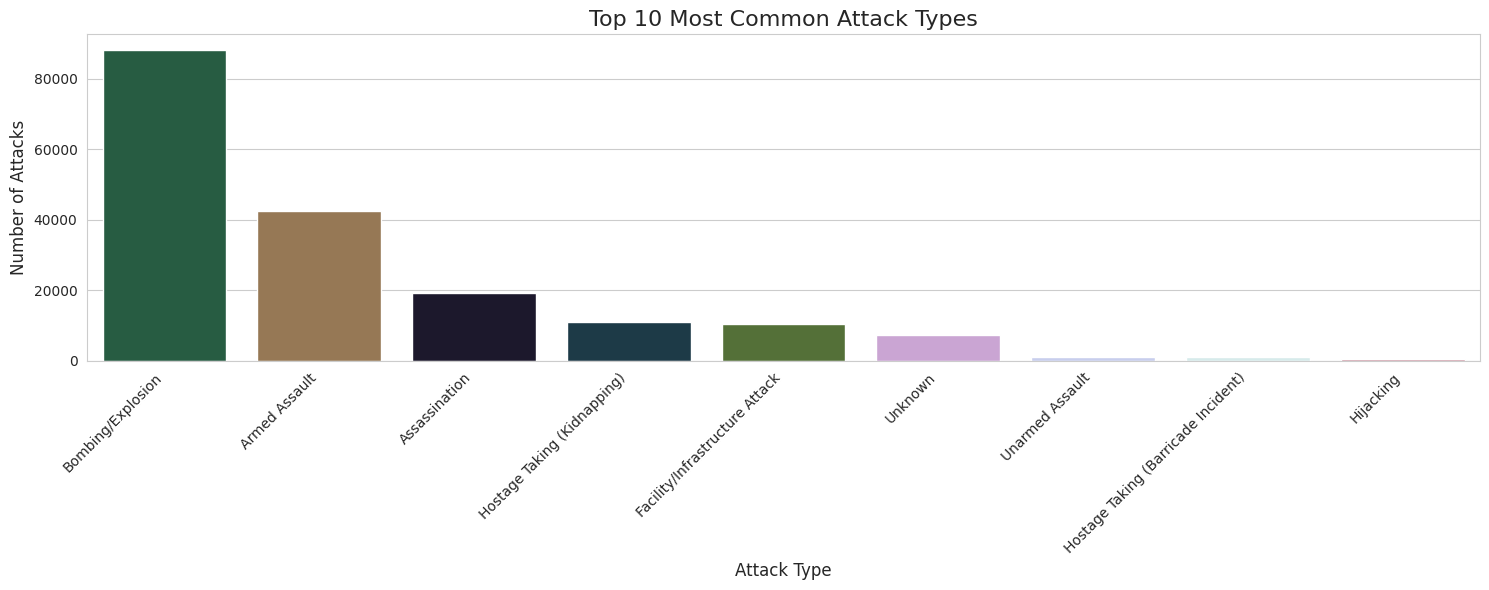

In [13]:
# Visualization 4: Top 10 most common attack types
plt.figure(figsize=(15, 6))
sns.countplot(x='attacktype1_txt', data=df, order=df['attacktype1_txt'].value_counts().index[:10], palette='cubehelix', hue='attacktype1_txt', legend=False)
plt.title('Top 10 Most Common Attack Types', fontsize=16)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

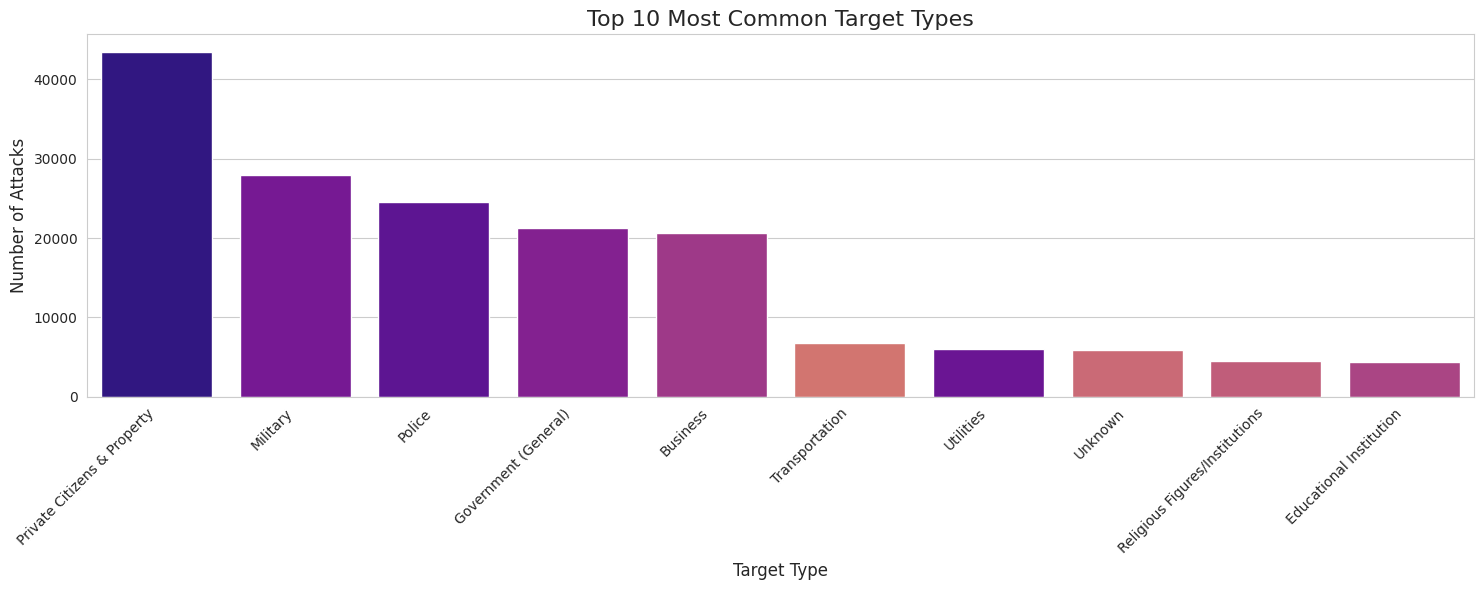

In [14]:
# Visualization 5: Top 10 most common targets
plt.figure(figsize=(15, 6))
sns.countplot(x='targtype1_txt', data=df, order=df['targtype1_txt'].value_counts().index[:10], palette='plasma', hue='targtype1_txt', legend=False)
plt.title('Top 10 Most Common Target Types', fontsize=16)
plt.xlabel('Target Type', fontsize=12)
plt.ylabel('Number of Attacks', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Casualty Analysis: Understanding the Impact of Attacks

To understand the impact of terrorist attacks, we will analyze the distribution of casualties, focusing on the number of people killed (`nkill`) and wounded (`nwound`).

In [15]:
print("Descriptive statistics for 'nkill':")
display(df['nkill'].describe())

print("\nDescriptive statistics for 'nwound':")
display(df['nwound'].describe())

Descriptive statistics for 'nkill':


,nkill
count,181691.000000
mean,2.266860
std,11.227057
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,1570.000000



Descriptive statistics for 'nwound':


,nwound
count,181691.000000
mean,2.883296
std,34.309747
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,8191.000000


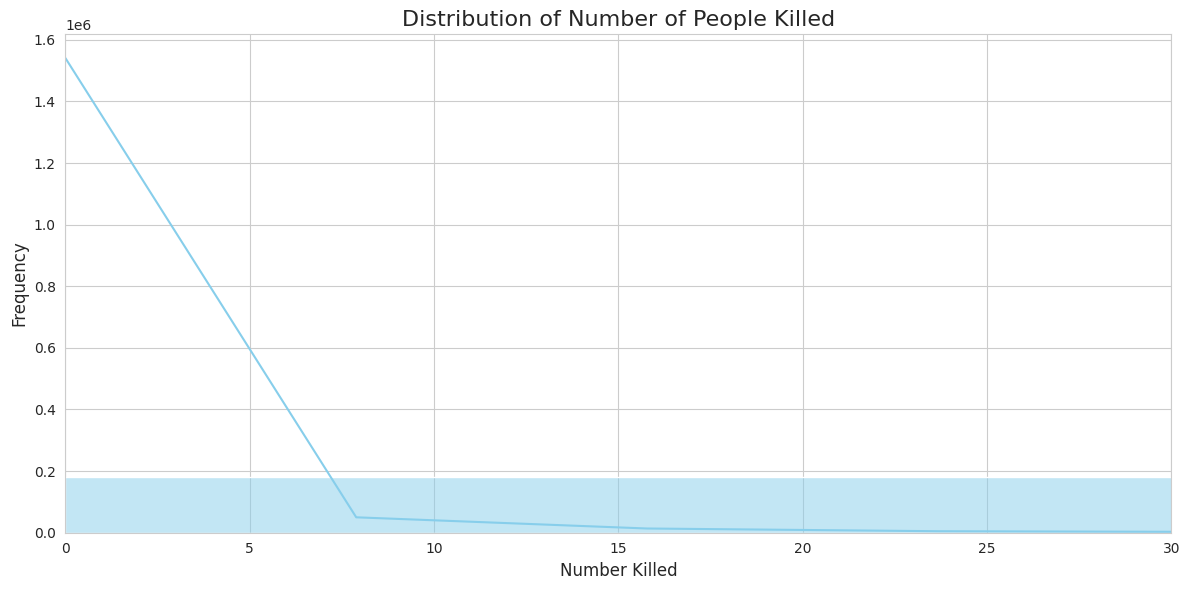

In [16]:
# Visualization 6: Distribution of people killed (nkill)
plt.figure(figsize=(12, 6))
sns.histplot(df['nkill'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Number of People Killed', fontsize=16)
plt.xlabel('Number Killed', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, df['nkill'].quantile(0.99)) # Limit x-axis to focus on the majority of data
plt.tight_layout()
plt.show()

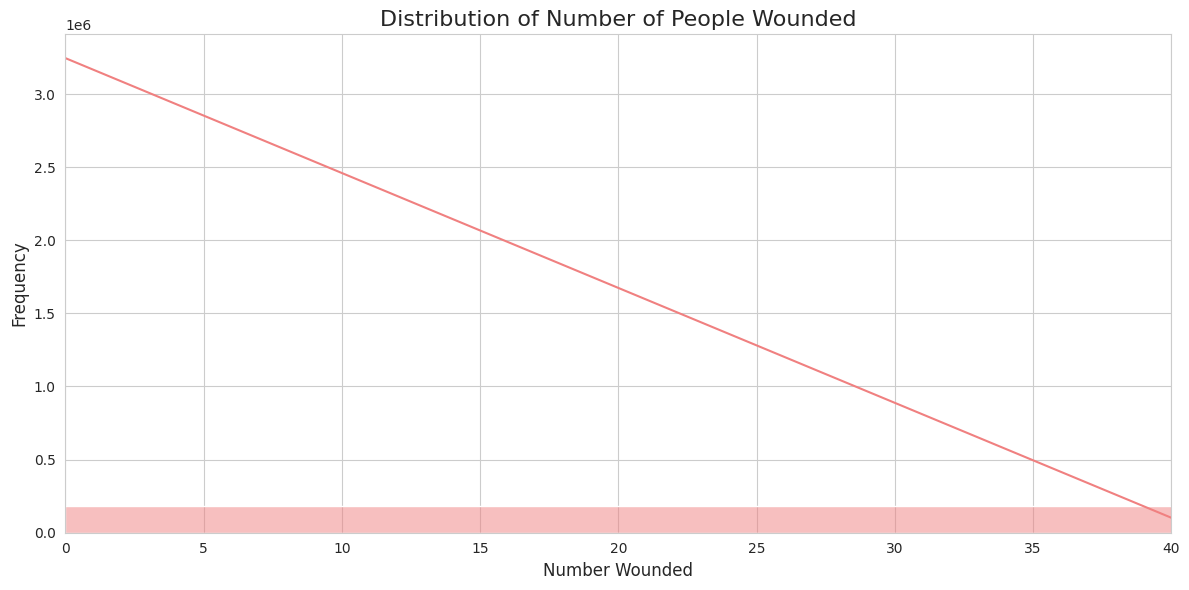

In [17]:
# Visualization 7: Distribution of people wounded (nwound)
plt.figure(figsize=(12, 6))
sns.histplot(df['nwound'], bins=50, kde=True, color='lightcoral')
plt.title('Distribution of Number of People Wounded', fontsize=16)
plt.xlabel('Number Wounded', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, df['nwound'].quantile(0.99)) # Limit x-axis to focus on the majority of data
plt.tight_layout()
plt.show()

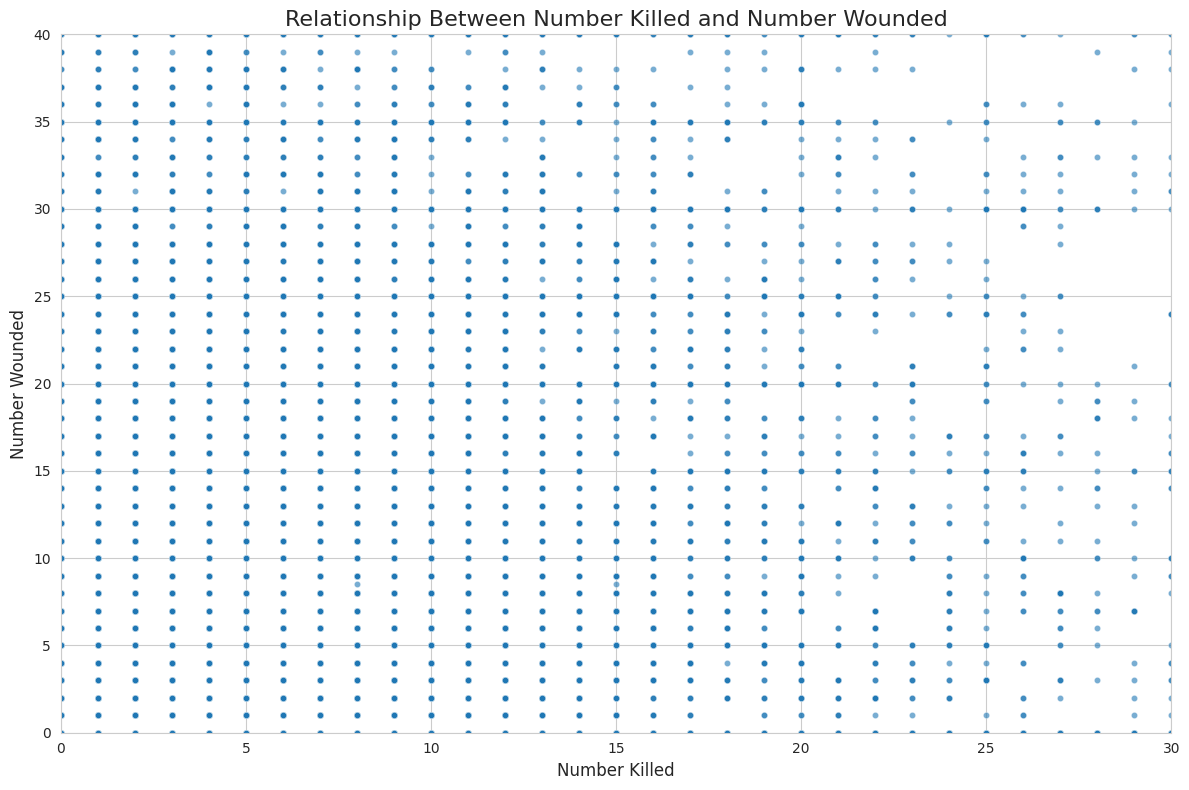

In [18]:
# Visualization 8: Relationship between killed and wounded
# Create a new column for total casualties for better understanding
df['total_casualties'] = df['nkill'] + df['nwound']

plt.figure(figsize=(12, 8))
sns.scatterplot(x='nkill', y='nwound', data=df, alpha=0.6, s=20)
plt.title('Relationship Between Number Killed and Number Wounded', fontsize=16)
plt.xlabel('Number Killed', fontsize=12)
plt.ylabel('Number Wounded', fontsize=12)
# Limit axes to focus on the most common range, excluding extreme outliers for better visualization
plt.xlim(0, df['nkill'].quantile(0.99))
plt.ylim(0, df['nwound'].quantile(0.99))
plt.tight_layout()
plt.show()